In [1]:

import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

import utils
import exp_models

In [2]:
# Reproducibility
SEED = 2019

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
#torch.backends.cudnn.enabled = False 
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [3]:
transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])
trainset = torchvision.datasets.CIFAR100(root='/data/landelle/datasets', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR100(root='/data/landelle/datasets', train=False, download=True, transform=transform)
#trainset, testset


Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 100
N_BATCHES_IN_TRAIN_SET = len(trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(testset) // BATCH_SIZE
NUM_WORKERS = 8

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


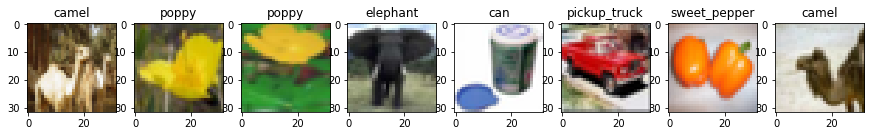

In [5]:
fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for images, labels in trainloader:
    for i in range(8):
        utils.show_np_arr(images[i], ax=axes[i])
        axes[i].set_title(trainset.classes[labels[i]])
    break

In [6]:

USE_CUDA = True
N_EPOCHS = 100
N_BATCHES = None
LR = 0.001

model_getter = lambda: exp_models.resnet18(n=100)

def perform_experiment(lambdas):
    print("saving results in", RESULTS_FNAME)
    print_ = utils.get_print(True, fname=RESULTS_FNAME)
    test_accs = {}
    train_losses = {str(k):[] for k in lambdas}
    val_losses = {str(k):[] for k in lambdas}
    train_losses = {str(k):[] for k in lambdas}
    
    for lambda_ in lambdas:
        print_("Trying lambda=", lambda_)        

        device = torch.device('cuda' if USE_CUDA else 'cpu')
        model = model_getter().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = torch.nn.CrossEntropyLoss()
        
        lam_rs = lambda_.reshape((-1, 1, 1, 1, 1))
        lam_rs_tensor = torch.from_numpy(lam_rs).float().to(device)
        
        NMIX = lam_rs_tensor.shape[0]
        print_("Performing n-mixup with N-mix:", NMIX)

        # Train mode
        model.train()
        for epoch in range(1, N_EPOCHS + 1):
            # Training on all batches
            print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
            for batch_id, (images, labels) in enumerate(trainloader):
                if N_BATCHES and batch_id > N_BATCHES:
                    break
                labels, images = labels.to(device), images.to(device)
                images_mx, ys, perms = utils.mixup_data_nmix(NMIX, images, labels, lam_rs_tensor, device)
                outputs = model(images_mx)
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
                loss_value = loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_losses[str(lambda_)].append(loss_value)
                if batch_id % 50 == 0:
                    print_('train loss:{:.4f} Epoch[{}/{}] Batch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET))
                    
            # Validating on one batch
            for images, labels in testloader:
                correct = 0
                total = 0
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                val_acc = 100 * correct / total
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
                loss_value = loss.item()

                print_('val loss:{:.4f} Epoch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS))
                print_('val acc:{:.4f} Epoch[{}/{}]'.format(
                        val_acc, epoch, N_EPOCHS))
                val_losses[str(lambda_)].append(loss_value)
                break

        # Test mode
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in testloader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            # Output test accuracy
            test_acc = 100 * correct / total
            print_('Test Accuracy of the model on the test images: {} %'.format(test_acc))
            test_accs[str(lambda_)] = test_acc


        del device, model, optimizer, criterion
    return test_accs, train_losses, images_mx, ys


In [9]:
N = 2

LAMBDAS = [np.array([1., 0.]), np.array([1., 0.]), np.array([1., 0.]), np.array([1., 0.]), np.array([1., 0.]), np.array([1., 0.])]

In [12]:


for i in range(5):
    RESULTS_FNAME = "r_cf100_rn18_n4_nomix2_" + str(i)    

    with open("results/"+RESULTS_FNAME, "w"):pass
    perform_experiment(LAMBDAS)
    print(RESULTS_FNAME, LAMBDAS)

saving results in r_cf100_rn18_n4_nomix2_0
Trying lambda= [1. 0.]
Performing n-mixup with N-mix: 2
Epoch[1/100]
train loss:4.7224 Epoch[1/100] Batch[0/500]
train loss:4.2724 Epoch[1/100] Batch[50/500]
train loss:4.1469 Epoch[1/100] Batch[100/500]
train loss:3.7270 Epoch[1/100] Batch[150/500]
train loss:3.5177 Epoch[1/100] Batch[200/500]
train loss:3.6613 Epoch[1/100] Batch[250/500]
train loss:3.5413 Epoch[1/100] Batch[300/500]
train loss:3.3897 Epoch[1/100] Batch[350/500]
train loss:3.3588 Epoch[1/100] Batch[400/500]
train loss:3.2283 Epoch[1/100] Batch[450/500]
val loss:6.7177 Epoch[1/100]
val acc:19.0000 Epoch[1/100]
Epoch[2/100]
train loss:3.1578 Epoch[2/100] Batch[0/500]
train loss:2.7170 Epoch[2/100] Batch[50/500]
train loss:2.9978 Epoch[2/100] Batch[100/500]
train loss:2.7546 Epoch[2/100] Batch[150/500]
train loss:2.5342 Epoch[2/100] Batch[200/500]
train loss:2.7724 Epoch[2/100] Batch[250/500]
train loss:2.6632 Epoch[2/100] Batch[300/500]
train loss:2.5089 Epoch[2/100] Batch[350/

train loss:0.0734 Epoch[16/100] Batch[100/500]
train loss:0.1009 Epoch[16/100] Batch[150/500]
train loss:0.1024 Epoch[16/100] Batch[200/500]
train loss:0.0767 Epoch[16/100] Batch[250/500]
train loss:0.0668 Epoch[16/100] Batch[300/500]
train loss:0.1208 Epoch[16/100] Batch[350/500]
train loss:0.1054 Epoch[16/100] Batch[400/500]
train loss:0.1453 Epoch[16/100] Batch[450/500]
val loss:20.9848 Epoch[16/100]
val acc:58.0000 Epoch[16/100]
Epoch[17/100]
train loss:0.0969 Epoch[17/100] Batch[0/500]
train loss:0.1104 Epoch[17/100] Batch[50/500]
train loss:0.1390 Epoch[17/100] Batch[100/500]
train loss:0.0822 Epoch[17/100] Batch[150/500]
train loss:0.0874 Epoch[17/100] Batch[200/500]
train loss:0.0406 Epoch[17/100] Batch[250/500]
train loss:0.0801 Epoch[17/100] Batch[300/500]
train loss:0.1334 Epoch[17/100] Batch[350/500]
train loss:0.1521 Epoch[17/100] Batch[400/500]
train loss:0.1553 Epoch[17/100] Batch[450/500]
val loss:22.1552 Epoch[17/100]
val acc:58.0000 Epoch[17/100]
Epoch[18/100]
train l

train loss:0.0725 Epoch[31/100] Batch[200/500]
train loss:0.0512 Epoch[31/100] Batch[250/500]
train loss:0.0342 Epoch[31/100] Batch[300/500]
train loss:0.0413 Epoch[31/100] Batch[350/500]
train loss:0.0412 Epoch[31/100] Batch[400/500]
train loss:0.0221 Epoch[31/100] Batch[450/500]
val loss:26.0775 Epoch[31/100]
val acc:60.0000 Epoch[31/100]
Epoch[32/100]
train loss:0.0108 Epoch[32/100] Batch[0/500]
train loss:0.0686 Epoch[32/100] Batch[50/500]
train loss:0.0445 Epoch[32/100] Batch[100/500]
train loss:0.0066 Epoch[32/100] Batch[150/500]
train loss:0.0048 Epoch[32/100] Batch[200/500]
train loss:0.0542 Epoch[32/100] Batch[250/500]
train loss:0.0511 Epoch[32/100] Batch[300/500]
train loss:0.0449 Epoch[32/100] Batch[350/500]
train loss:0.0697 Epoch[32/100] Batch[400/500]
train loss:0.0965 Epoch[32/100] Batch[450/500]
val loss:25.3217 Epoch[32/100]
val acc:53.0000 Epoch[32/100]
Epoch[33/100]
train loss:0.0297 Epoch[33/100] Batch[0/500]
train loss:0.0265 Epoch[33/100] Batch[50/500]
train loss

train loss:0.0197 Epoch[46/100] Batch[300/500]
train loss:0.0027 Epoch[46/100] Batch[350/500]
train loss:0.0090 Epoch[46/100] Batch[400/500]
train loss:0.0040 Epoch[46/100] Batch[450/500]
val loss:28.9132 Epoch[46/100]
val acc:59.0000 Epoch[46/100]
Epoch[47/100]
train loss:0.0096 Epoch[47/100] Batch[0/500]
train loss:0.0011 Epoch[47/100] Batch[50/500]
train loss:0.0009 Epoch[47/100] Batch[100/500]
train loss:0.0338 Epoch[47/100] Batch[150/500]
train loss:0.0146 Epoch[47/100] Batch[200/500]
train loss:0.0741 Epoch[47/100] Batch[250/500]
train loss:0.0172 Epoch[47/100] Batch[300/500]
train loss:0.0068 Epoch[47/100] Batch[350/500]
train loss:0.0169 Epoch[47/100] Batch[400/500]
train loss:0.0419 Epoch[47/100] Batch[450/500]
val loss:29.3136 Epoch[47/100]
val acc:56.0000 Epoch[47/100]
Epoch[48/100]
train loss:0.0116 Epoch[48/100] Batch[0/500]
train loss:0.0604 Epoch[48/100] Batch[50/500]
train loss:0.0206 Epoch[48/100] Batch[100/500]
train loss:0.0306 Epoch[48/100] Batch[150/500]
train loss

train loss:0.0150 Epoch[61/100] Batch[400/500]
train loss:0.0126 Epoch[61/100] Batch[450/500]
val loss:30.5699 Epoch[61/100]
val acc:57.0000 Epoch[61/100]
Epoch[62/100]
train loss:0.0013 Epoch[62/100] Batch[0/500]
train loss:0.0146 Epoch[62/100] Batch[50/500]
train loss:0.0428 Epoch[62/100] Batch[100/500]
train loss:0.0032 Epoch[62/100] Batch[150/500]
train loss:0.0036 Epoch[62/100] Batch[200/500]
train loss:0.0063 Epoch[62/100] Batch[250/500]
train loss:0.0235 Epoch[62/100] Batch[300/500]
train loss:0.0164 Epoch[62/100] Batch[350/500]
train loss:0.0377 Epoch[62/100] Batch[400/500]
train loss:0.0537 Epoch[62/100] Batch[450/500]
val loss:29.7258 Epoch[62/100]
val acc:57.0000 Epoch[62/100]
Epoch[63/100]
train loss:0.0463 Epoch[63/100] Batch[0/500]
train loss:0.0356 Epoch[63/100] Batch[50/500]
train loss:0.0026 Epoch[63/100] Batch[100/500]
train loss:0.0053 Epoch[63/100] Batch[150/500]
train loss:0.0262 Epoch[63/100] Batch[200/500]
train loss:0.0438 Epoch[63/100] Batch[250/500]
train loss

...

val loss:30.1142 Epoch[67/100]
val acc:56.0000 Epoch[67/100]
Epoch[68/100]
train loss:0.0342 Epoch[68/100] Batch[0/500]
train loss:0.0081 Epoch[68/100] Batch[50/500]
train loss:0.0101 Epoch[68/100] Batch[100/500]
train loss:0.0028 Epoch[68/100] Batch[150/500]
train loss:0.0022 Epoch[68/100] Batch[200/500]
train loss:0.0090 Epoch[68/100] Batch[250/500]
train loss:0.0214 Epoch[68/100] Batch[300/500]
train loss:0.0277 Epoch[68/100] Batch[350/500]
train loss:0.0252 Epoch[68/100] Batch[400/500]
train loss:0.0182 Epoch[68/100] Batch[450/500]
val loss:28.3263 Epoch[68/100]
val acc:58.0000 Epoch[68/100]
Epoch[69/100]
train loss:0.0546 Epoch[69/100] Batch[0/500]
train loss:0.0002 Epoch[69/100] Batch[50/500]
train loss:0.0009 Epoch[69/100] Batch[100/500]
train loss:0.0031 Epoch[69/100] Batch[150/500]
train loss:0.0020 Epoch[69/100] Batch[200/500]
train loss:0.0005 Epoch[69/100] Batch[250/500]
train loss:0.0031 Epoch[69/100] Batch[300/500]
train loss:0.0122 Epoch[69/100] Batch[350/500]
train loss

train loss:0.0345 Epoch[83/100] Batch[0/500]
train loss:0.0177 Epoch[83/100] Batch[50/500]
train loss:0.0007 Epoch[83/100] Batch[100/500]
train loss:0.0064 Epoch[83/100] Batch[150/500]
train loss:0.0018 Epoch[83/100] Batch[200/500]
train loss:0.0393 Epoch[83/100] Batch[250/500]
train loss:0.0047 Epoch[83/100] Batch[300/500]
train loss:0.0541 Epoch[83/100] Batch[350/500]
train loss:0.0322 Epoch[83/100] Batch[400/500]
train loss:0.0007 Epoch[83/100] Batch[450/500]
val loss:32.6305 Epoch[83/100]
val acc:59.0000 Epoch[83/100]
Epoch[84/100]
train loss:0.0042 Epoch[84/100] Batch[0/500]
train loss:0.0078 Epoch[84/100] Batch[50/500]
train loss:0.0011 Epoch[84/100] Batch[100/500]
train loss:0.0369 Epoch[84/100] Batch[150/500]
train loss:0.0021 Epoch[84/100] Batch[200/500]
train loss:0.0008 Epoch[84/100] Batch[250/500]
train loss:0.0033 Epoch[84/100] Batch[300/500]
train loss:0.0199 Epoch[84/100] Batch[350/500]
train loss:0.0094 Epoch[84/100] Batch[400/500]
train loss:0.0108 Epoch[84/100] Batch[

train loss:0.0008 Epoch[98/100] Batch[100/500]
train loss:0.0191 Epoch[98/100] Batch[150/500]
train loss:0.0079 Epoch[98/100] Batch[200/500]
train loss:0.0360 Epoch[98/100] Batch[250/500]
train loss:0.0020 Epoch[98/100] Batch[300/500]
train loss:0.0043 Epoch[98/100] Batch[350/500]
train loss:0.0007 Epoch[98/100] Batch[400/500]
train loss:0.0058 Epoch[98/100] Batch[450/500]
val loss:33.9074 Epoch[98/100]
val acc:58.0000 Epoch[98/100]
Epoch[99/100]
train loss:0.0099 Epoch[99/100] Batch[0/500]
train loss:0.0027 Epoch[99/100] Batch[50/500]
train loss:0.0105 Epoch[99/100] Batch[100/500]
train loss:0.0279 Epoch[99/100] Batch[150/500]
train loss:0.0038 Epoch[99/100] Batch[200/500]
train loss:0.0029 Epoch[99/100] Batch[250/500]
train loss:0.0044 Epoch[99/100] Batch[300/500]
train loss:0.0247 Epoch[99/100] Batch[350/500]
train loss:0.0060 Epoch[99/100] Batch[400/500]
train loss:0.0514 Epoch[99/100] Batch[450/500]
val loss:32.4146 Epoch[99/100]
val acc:58.0000 Epoch[99/100]
Epoch[100/100]
train 

train loss:0.1684 Epoch[13/100] Batch[200/500]
train loss:0.1068 Epoch[13/100] Batch[250/500]
train loss:0.0831 Epoch[13/100] Batch[300/500]
train loss:0.1278 Epoch[13/100] Batch[350/500]
train loss:0.1871 Epoch[13/100] Batch[400/500]
train loss:0.1934 Epoch[13/100] Batch[450/500]
val loss:19.8749 Epoch[13/100]
val acc:63.0000 Epoch[13/100]
Epoch[14/100]
train loss:0.0835 Epoch[14/100] Batch[0/500]
train loss:0.0576 Epoch[14/100] Batch[50/500]


KeyboardInterrupt: 

In [10]:
m = exp_models.resnet18(n=100)


device = torch.device('cuda' if USE_CUDA else 'cpu')
m.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=